# VQMAP Basic Usage Tutorial

This notebook demonstrates model training, inference, and visualization of the learned codebook.

### Dependencies & setup

In [1]:
import os
import matplotlib.pyplot as plt
import torch
from vqmap.utils.visualize import *
from sklearn.decomposition import PCA

/home/tianqingli/anaconda3/envs/vqmap/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# change directory to the source's root (only for this tutorial)
os.chdir('..')

## Prepare dataset

Download the demo data from this Box [link](https://duke.box.com/s/ft7dzngs5pt3wuyhg4ztmg9zav6sre54), which includes 30 sessions of tracked 3D kinematics of unconstrained rats. 

In [3]:
# replace ROOT with directory where the data was placed 
ROOT = '.'
DATAROOT = ROOT + '/rat_raw_predictions_demo.npy'
assert os.path.exists(DATAROOT)

# Model training

All the training configurations are specified by a master `.yaml` config file, which we specify in `config_path`. Each entry in the master config file points to some sub-level config file (e.g., `dataset`, `model`). The user may also specify settings in the command line, as we demonstrate below.

Here we simply use the default settings to train a hierarchical VQMAP model with two codebooks (size = 8, 12).

In [4]:
CONFIG_PATH = './configs/base/demo.yaml'
EXPDIR = './experiments/demo/trial0' # project directory, change if needed

!python train.py $CONFIG_PATH \
    expdir=$EXPDIR \
    dataset.root=$DATAROOT \
    train.epochs=50 # use a larger number of epochs in actual training; here is for demo only

2024-02-26 11:17:52.945 | INFO     | __main__:main:38 - Set random seed to: 1024

2024-02-26 11:17:52.945 | INFO     | vqmap.datasets:initialize_dataset_single:193 - Split dataset by fraction
2024-02-26 11:17:52.951 | INFO     | vqmap.utils.skeleton:__init__:87 - Pose profile: rat23
2024-02-26 11:17:52.951 | INFO     | vqmap.utils.skeleton:__init__:88 - Number of keypoints: 23
2024-02-26 11:17:52.952 | INFO     | vqmap.utils.skeleton:__init__:91 - Kinematic tree: 
2024-02-26 11:17:52.952 | INFO     | vqmap.utils.skeleton:__init__:93 -      Chain: ['SpineM', 'SpineF', 'EarL', 'EarR', 'Snout']
2024-02-26 11:17:52.952 | INFO     | vqmap.utils.skeleton:__init__:93 -      Chain: ['SpineM', 'SpineL', 'TailBase']
2024-02-26 11:17:52.952 | INFO     | vqmap.utils.skeleton:__init__:93 -      Chain: ['SpineF', 'ShoulderL', 'ELbowL', 'WristL', 'HandL']
2024-02-26 11:17:52.952 | INFO     | vqmap.utils.skeleton:__init__:93 -      Chain: ['SpineF', 'ShoulderR', 'ELbowR', 'WristR', 'HandR']
2024-02-26

# Visualization of the learned codebook

Running the script `inference.py` with `mode=all` will automatically embed all data (train, validation) into code representations using the specified model checkpoint, decode the learned codebook vectors into corresponding kinematics and visualize a random sequence before & after reconstruction.

In [8]:
checkpoint_path = os.path.join(EXPDIR, 'model_last.pth')
!python inference.py $checkpoint_path --mode="all"

2024-02-26 11:33:05.936 | INFO     | __main__:main:36 - Set random seed to: 1024

2024-02-26 11:33:05.944 | INFO     | vqmap.utils.skeleton:__init__:87 - Pose profile: rat23
2024-02-26 11:33:05.944 | INFO     | vqmap.utils.skeleton:__init__:88 - Number of keypoints: 23
2024-02-26 11:33:05.944 | INFO     | vqmap.utils.skeleton:__init__:91 - Kinematic tree: 
2024-02-26 11:33:05.944 | INFO     | vqmap.utils.skeleton:__init__:93 -      Chain: ['SpineM', 'SpineF', 'EarL', 'EarR', 'Snout']
2024-02-26 11:33:05.944 | INFO     | vqmap.utils.skeleton:__init__:93 -      Chain: ['SpineM', 'SpineL', 'TailBase']
2024-02-26 11:33:05.944 | INFO     | vqmap.utils.skeleton:__init__:93 -      Chain: ['SpineF', 'ShoulderL', 'ELbowL', 'WristL', 'HandL']
2024-02-26 11:33:05.944 | INFO     | vqmap.utils.skeleton:__init__:93 -      Chain: ['SpineF', 'ShoulderR', 'ELbowR', 'WristR', 'HandR']
2024-02-26 11:33:05.944 | INFO     | vqmap.utils.skeleton:__init__:93 -      Chain: ['SpineL', 'HipL', 'KneeL', 'AnkleL'

Let's visualize the codebook here, after exhausitively combining all TCs & BCs and decoding.

Text(0, 0.5, 'Top code (TC)')

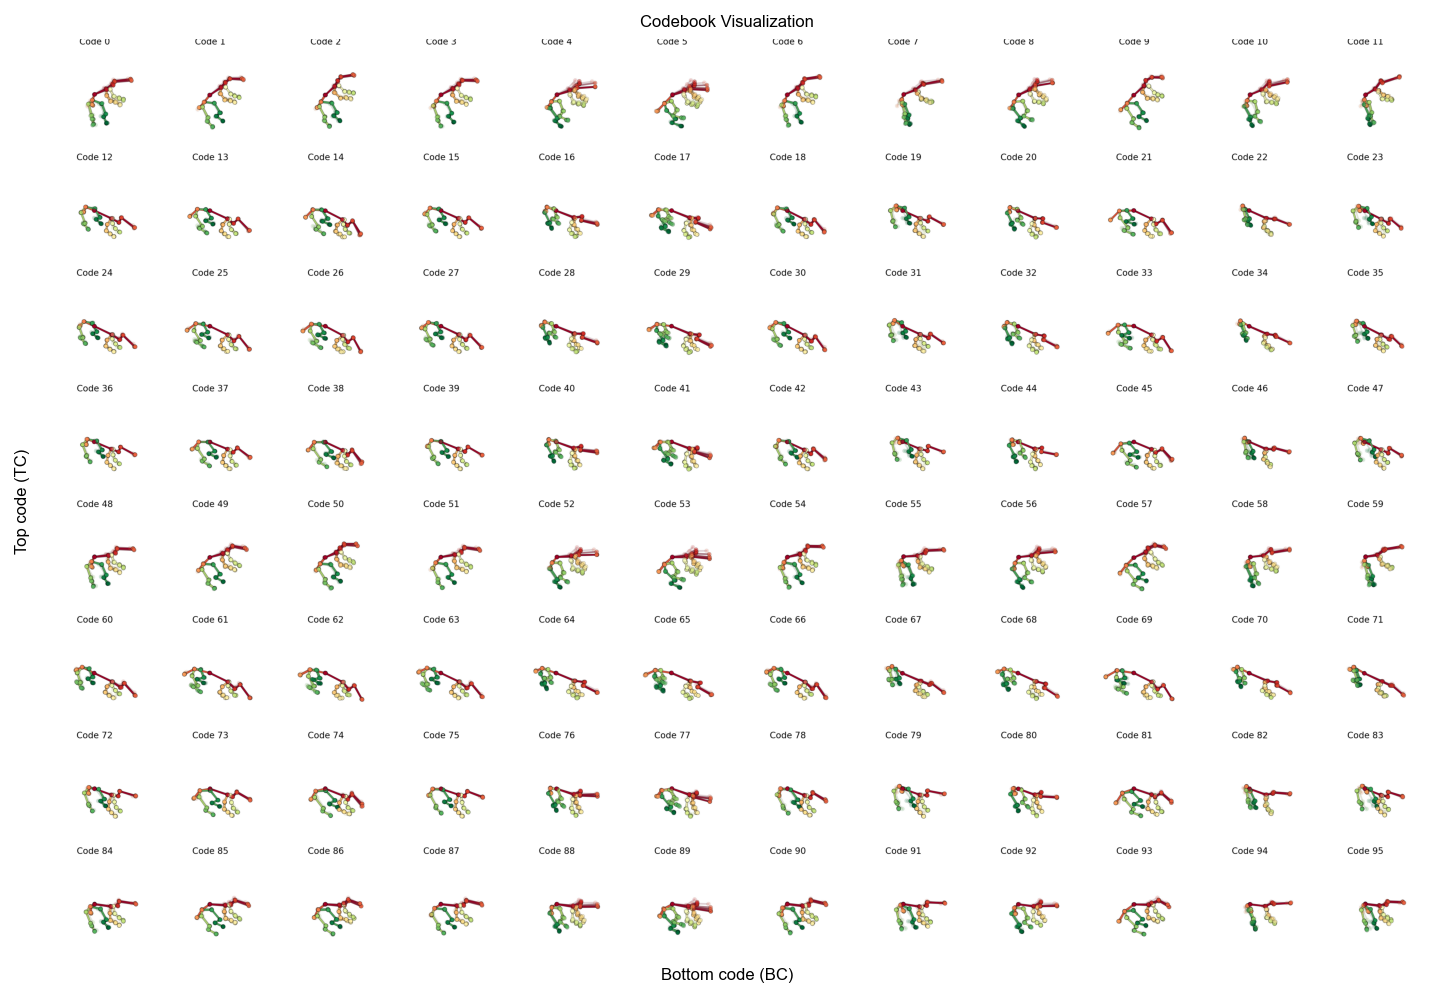

In [9]:
codebook_vis_path = os.path.join(EXPDIR, 'vis_codebook.png')
codebook_vis = plt.imread(codebook_vis_path)
reset_rcparams()
fig, ax = plt.subplots(1, 1, dpi=150, figsize=(12, 8))
ax.imshow(codebook_vis)
hide_axes_all(ax)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Codebook Visualization', fontsize=8)
ax.set_xlabel('Bottom code (BC)', fontsize=8)
ax.set_ylabel('Top code (TC)', fontsize=8)

We could further sort the discrete latent space for better visualization.

In [10]:
# load the embedding vectors
ckpt = torch.load(os.path.join(EXPDIR, 'model_last.pth'))
nb_code = ckpt['config'].model.bottleneck.args.nb_code
state_dict = ckpt["model"]
codebook_keys = [k for k in state_dict.keys() if 'quantizer' in k]
codebooks = [state_dict[k].detach().cpu().numpy() for k in codebook_keys]

# sort the TC by similarity
rearing_idx = 0 # REPLACE here with the ROW idx representing high rears
X = deepcopy(codebooks[0])
sim = X @ X.T
motif_order0 = np.argsort(sim[rearing_idx])[::-1]

# sort the BC by PC1
X = deepcopy(codebooks[1])
pca = PCA(n_components=2)
pca.fit(X)
print("Explained variance:", pca.explained_variance_ratio_)
X_reduced = pca.transform(X)
pc_sort = np.argsort(X_reduced, axis=0)
motif_order1 = pc_sort[:, 0]

Explained variance: [0.9401733  0.05812805]


Text(0, 0.5, 'Top code (TC)')

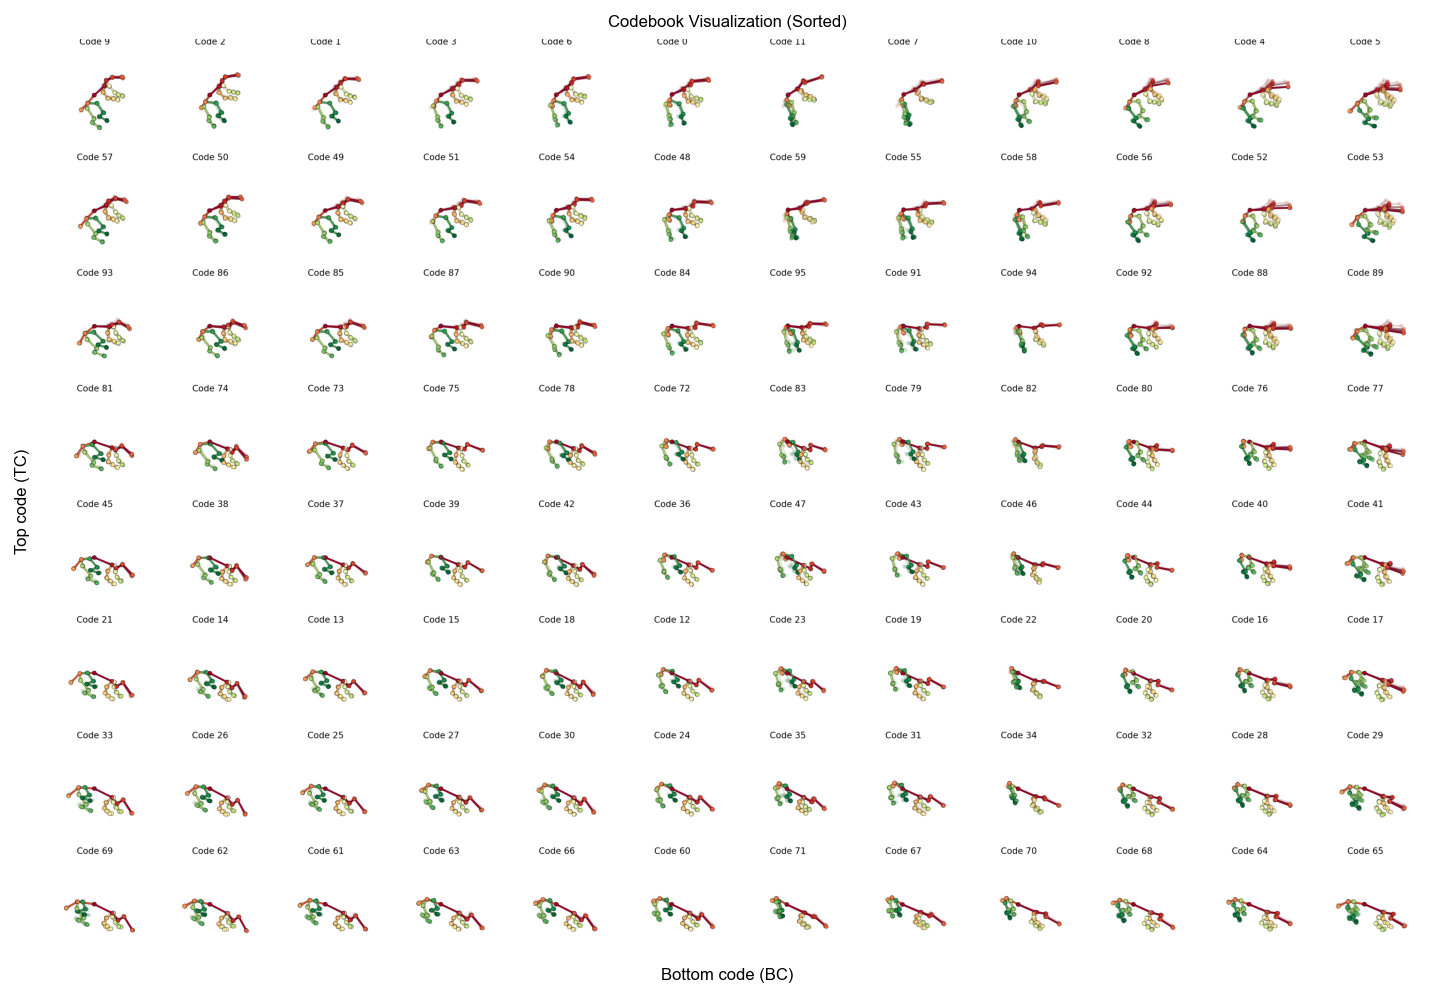

In [11]:
savepath = os.path.join(EXPDIR, 'vis')
overlap = 15
w = nb_code[0]
full = []
for row in motif_order0:
    indices = [row*nb_code[1]+i for i in motif_order1]
    ims = [
        plt.imread(savepath+f'/code{idx}.png')[overlap:-overlap, overlap:-overlap, :]
        for idx in indices
    ]
    ims = np.concatenate(ims, axis=1)
    full.append(ims)
full = np.concatenate(full, axis=0)

fig, ax = plt.subplots(1, 1, dpi=150, figsize=(12, 8))
ax.imshow(full)
hide_axes_all(ax)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Codebook Visualization (Sorted)', fontsize=8)
ax.set_xlabel('Bottom code (BC)', fontsize=8)
ax.set_ylabel('Top code (TC)', fontsize=8)

From the inferred codes, we can examine the overall code usage/occupancy in the behavioral map.

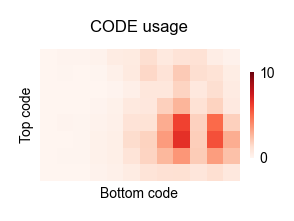

In [15]:
codes = np.load(
    os.path.join(EXPDIR, 'vq_code_MocapSimpleCompiled.npy'), 
    allow_pickle=True,
)[()]["code"]


reset_rcparams()
fig, ax = plt.subplots(1, 1, figsize=(40*MM, 40*MM), dpi=200)
code_reindex = codes[:, 0] * nb_code[1] + codes[:, 1]
uniques, counts = np.unique(code_reindex, return_counts=True)
usage = np.zeros(nb_code[0]*nb_code[1])
usage[uniques] = counts / sum(counts) * 100
usage = usage.reshape((nb_code[0], nb_code[1]))
usage = usage[motif_order0]
usage = usage[:, motif_order1]

im = ax.imshow(usage, cmap='Reds', vmin=0, vmax=10)
ax.spines[:].set_visible(False)
hide_axes_all(ax)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"CODE usage", fontsize=6)
ax.set_xlabel("Bottom code")
ax.set_ylabel("Top code")

# Create colorbar
cbar = ax.figure.colorbar(
    im, ax=ax, fraction=0.02, pad=0.05, 
)
cbar.outline.set_linewidth(0)
cbar.set_ticks([0, 10])
cbar.ax.tick_params(which='major', length=0, )

plt.tight_layout()